In [6]:
# imports 
import numpy as np
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
import equinox as eqx

rng = np.random.default_rng(0)

In [7]:
# Set EMRI params and create synthetic data
emri_params = {
    'm1': 1e6, 
    'm2': 10.0, 
    'a': 0.99, 
    'p0': 7.0, 
    'e0': 0.7, 
    'x0': 1.0,
    'dist': 1.0, 
    'qS': 0.2, 
    'phiS': 0.2, 
    'qK': 0.8, 
    'phiK': 0.8,
    'Phi_phi0': 0.0, 
    'Phi_theta0': 0.0, 
    'Phi_r0': 0.0, 
    'T': 2.0, 
    'dt': 5.0
}

In [8]:
#  Load FEW trajectory and comp-ute T_plunge and e_f
from few. trajectory.inspiral import EMRIInspiral
traj = EMRIInspiral(func='KerrEccEqFlux')

In [9]:
traj_pars= traj_pars = [
    emri_params['m1'], 
    emri_params['m2'], 
    emri_params['a'], 
    emri_params['p0'], 
    emri_params['e0'], 
    emri_params['x0']
    ]
t, p, e, xI, Phi_phi, Phi_theta, Phi_r = traj(*traj_pars, T=emri_params['T'])

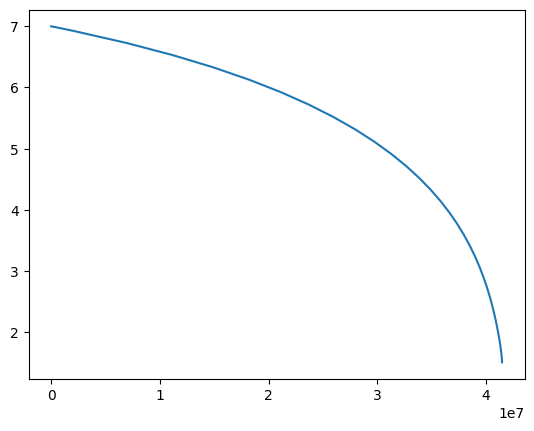

In [10]:
import matplotlib.pyplot as plt
plt.plot(t, p)

In [11]:
print(f'Final p: {p[-1]}, Final e: {e[-1]}')

Final p: 1.504808821388181, Final e: 0.0817159597127215


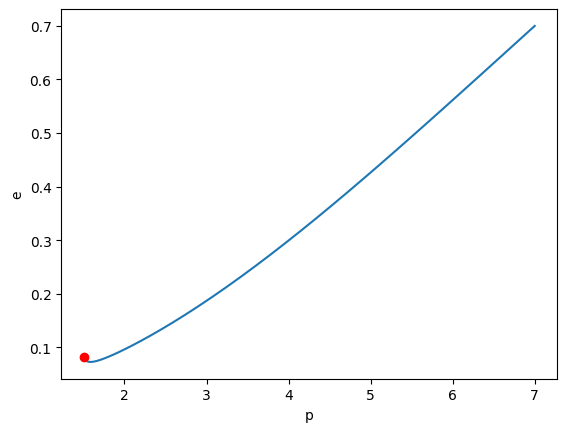

In [12]:
# phase space plot
plt.plot(p, e)
plt.xlabel('p')
plt.ylabel('e')

# indicate plunge with a red dot
plt.plot(p[-1], e[-1], 'ro')

In [13]:
# Generate synthetic data and transform into SFTs
# Use Lorenzo's function for this
from few.utils.constants import YRSID_SI
from emrisearch.search_utils import generate_emri_signal_and_sfts
from emrisearch.emri_utils import get_f_fdot_fddot_back
from emrisearch.jax_utils import det_stat as jax_det_stat, psd
from emrisearch.track_optimizer import (
    TrackOptimizer, TrackOptimizerJAX, estimate_plunge_time,
    get_default_mode_candidates, DEFAULT_BOUNDS,
)

print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


In [14]:
t

array([0.00000000e+00, 1.96028491e+04, 6.58585870e+04, 1.87005953e+05,
       5.23915125e+05, 2.02599571e+06, 6.95413803e+06, 1.11650980e+07,
       1.49003548e+07, 1.82041475e+07, 2.11277883e+07, 2.37043810e+07,
       2.59721631e+07, 2.79785178e+07, 2.97389685e+07, 3.12874086e+07,
       3.26471390e+07, 3.38405669e+07, 3.48871857e+07, 3.58036932e+07,
       3.66097362e+07, 3.73177735e+07, 3.79391435e+07, 3.84851852e+07,
       3.89654326e+07, 3.93837476e+07, 3.97444304e+07, 4.00508595e+07,
       4.03091683e+07, 4.05286313e+07, 4.07192063e+07, 4.08598110e+07,
       4.09798398e+07, 4.10724009e+07, 4.11472661e+07, 4.12082499e+07,
       4.12584162e+07, 4.12991958e+07, 4.13326468e+07, 4.13600843e+07,
       4.13818572e+07, 4.13986299e+07, 4.14128541e+07, 4.14238036e+07,
       4.14324057e+07, 4.14394727e+07, 4.14450644e+07, 4.14494398e+07,
       4.14528136e+07, 4.14554138e+07, 4.14574026e+07, 4.14589214e+07,
       4.14600898e+07, 4.14609777e+07, 4.14616495e+07, 4.14621554e+07,
      

In [15]:
t[-1]/YRSID_SI

np.float64(1.3138773059095477)

In [16]:
emri_params['T_plunge'] = t[-1]/YRSID_SI
emri_params['e_f'] = e[-1]
emri_params['p_sep'] = p[-1]

In [17]:
true_values = np.array([emri_params['m1'], 
                        emri_params['m2'], 
                        emri_params['a'], 
                        emri_params['T_plunge'], 
                        emri_params['e_f'], 
                        emri_params['x0']])

T_data  = 0.2     # years (short, for a fast demo)
T_sft   = 5e4     # seconds (~14 h)
deltaT  = 5.0     # seconds
snr_ref = 30.0

In [1]:
from emrisearch.da_utils import psd, sft_inner_product, compute_sfts, generate_noise, get_snr

Using TDI PSD
Using TDI PSD


In [3]:
from emrisearch.emri_utils import create_signal, get_f_fdot_fddot_back   

In [ ]:
# we load one of the Mojito datasets and generate noise for it from the PSD, then sum signal + noise and compute the SFTs
# fastlisaresponse + FEW is broken by some recent updates,

In [4]:
def generate_emri_signal_and_sfts(true_values, T_data, T_sft, deltaT, snr_ref, T_snr):
    """
    Generate EMRI signal, compute SFTs, and prepare data for analysis.
    
    Parameters:
    -----------
    true_values : np.ndarray
        EMRI parameters [m1, m2, a, Tpl, ef, x0]
    T_data : float
        Total data duration in years
    T_sft : float
        SFT duration in seconds
    deltaT : float
        Time step in seconds
    snr_ref : float
        SNR of the signal with duration T_snr
    T_snr : float
        Duration of the signal in years it must be always bigger or equal to T_data

    Returns:
    --------
    dict : Dictionary containing:
        - 't': trimmed time array
        - 'signal_sfts': SFTs of the signal
        - 'noise_sfts': SFTs of noise realization
        - 'new_noise_sfts': SFTs of second noise realization
        - 'data_sfts': SFTs of signal + noise
        - 't_alpha': time samples for SFTs
        - 'samples_per_sft': number of samples per SFT
        - 'wind': window function
        - 'snr_final': final SNR of scaled signal
        - 'true_phi_f_fdot_fddot': frequency evolution parameters
    """
    # Generate EMRI signal
    t, hp, hx, param_dict = create_signal(true_values, T=T_snr, deltaT=deltaT, return_params=True, randomize=True)
    snr_sig = get_snr(hp, deltaT)  # Check SNR of the signal
    
    # Trim signal to desired duration
    mask = t < YRSID_SI * T_data
    hp, hx = snr_ref/snr_sig * hp[mask], snr_ref/snr_sig * hx[mask]  # Rescale signal to desired SNR
    t = t[mask]
    snr_final = get_snr(hp, deltaT)  
    print(f"Final SNR: {snr_final}")
    
    # update distance
    param_dict['dist'] = param_dict['dist'] * snr_sig/snr_ref
    
    # SFT parameters
    samples_per_sft = int(T_sft/deltaT) 
    wind = tukey(samples_per_sft, 0.2)  # Window function 
    
    # Compute SFTs
    signal_sfts = compute_sfts(hp, deltaT, wind, samples_per_sft)
    num_sfts = signal_sfts.shape[1]
    t_alpha = np.arange(num_sfts) * T_sft
    
    # Generate noise SFTs
    noise_td = generate_noise(hp.shape[0], deltaT, psd)
    data_td = hp + noise_td
    noise_sfts = compute_sfts(noise_td, deltaT, wind, samples_per_sft)
    new_noise_sfts = compute_sfts(generate_noise(hp.shape[0], deltaT, psd), deltaT, wind, samples_per_sft)
    data_sfts = signal_sfts + noise_sfts
    
    # compute matched filtering
    freq = np.fft.rfftfreq(samples_per_sft, deltaT)
    m_hd = sft_inner_product(signal_sfts, data_sfts, freq)
    m_hh = sft_inner_product(signal_sfts, signal_sfts, freq)
    m_hn = sft_inner_product(signal_sfts, noise_sfts, freq)

    # Get frequency evolution for true values
    true_phi_f_fdot_fddot = get_f_fdot_fddot_back(true_values, t_alpha)
    
    return {
        'data_td': data_td,
        'param_dict': param_dict,
        't': t,
        'data_sfts': data_sfts,
        'signal_sfts': signal_sfts,
        'noise_sfts': noise_sfts,
        'new_noise_sfts': new_noise_sfts,
        't_alpha': t_alpha,
        'samples_per_sft': samples_per_sft,
        'num_sfts': num_sfts,
        'wind': wind,
        'snr_final': snr_final,
        'true_phi_f_fdot_fddot': true_phi_f_fdot_fddot,
        'm_hd': m_hd,
        'm_hh': m_hh,
        'm_hn': m_hn
    }

In [18]:
# create dictionary with signal noise and SFTs
injection = generate_emri_signal_and_sfts(
    true_values, T_data, T_sft, deltaT, snr_ref, T_data
)

: 

In [ ]:
data_sfts = jnp.asarray(injection["data_sfts"])

Modified Viterbi algorithm: pick a starting frequency f, fdot . Then we approximate the signal as a slowly-varying chirp-like signal and use the Fresnel kernel to get the SFT representation

We use the Viterbi algorithm to find the track through the data that maximizes the excess power against the noise. We make the following checks:
- Sum power along the true track and compare to the expected power from the PSD of the data across this time-frequency track. 
- We accumulate power in the following way: use f, fdot slowly varying chirp-like signal as the fundamental harmonic and then we make use of the property that higher hamonics are integer multiples of the fundamental harmonic. We also know that the fundamental harmonic does always chip upwards and so we impose the constrainst:
    - $f_i >=f_{i-1}$
    - $\dot{f}_i > 0$

We have the data grid resolution in time and frequency N_txN_f = T_data/dt as a rule of thumb. We need to clarify how we will impose f, fdot on this grid. 

In [ ]:
import jax.lax as lax

#define the forwrard and backtrack functions for the Viterbi algorithm

@jax.jit
def viterbi_forward(emission, log_trans):
    def step(V_prev, E_a):
        scores    = V_prev[:, None] + log_trans      # (S_prev, S_next)
        best_prev = jnp.argmax(scores, axis=0)       # (S_next,)
        V         = E_a + jnp.max(scores, axis=0)     # (S_next,)
        return V, best_prev
    V0 = emission[0]   # no transition into segment 0
    V_last, backptrs = lax.scan(step, V0, emission[1:])
    return V_last, backptrs   # backptrs: (N_seg-1, S)

def viterbi_backtrack(V_last, backptrs):
    # Host-side backtrack: integer state path of length N_seg.
    backptrs = np.asarray(backptrs)
    N = backptrs.shape[0] + 1
    path = np.empty(N, dtype=int)
    path[-1] = int(jnp.argmax(V_last))
    for i in range(N - 2, -1, -1):
        path[i] = backptrs[i][path[i + 1]]
    return path

# Full multi-harmonic Viterbi search on the EMRI spectrogram

Putting the pieces together on the real `data_sfts` from `generate_emri_signal_and_sfts`. 

The latent state is the pair of fundamentals $(f_{az}, f_r)$, the emission sums the whitened spectrogram over the harmonic combination $f_{mn}=m f_{az}+n f_r$, and the transition matrixenforces the inspiral physics (chirp-up + continuity) by putting nan in invalid transitions. The search then:

- Whiten the SFT power by the PSD (colored LISA noise) and centre it, so off-track cells average to zero.
-Build the **joint $(f_{az},f_r)$ grid** and the **multi-harmonic emission** (comb gather table).
- Impose the **constraints** in the transition matrix: $\dot f>0$ (chirp-up) and bounded drift per segment (continuity).
- Run the search. Random starting frequencies evolved under the constraints give a baseline. We use the Viterbi dynamic program over all starting frequencies and all continuity-respecting paths jointly, and returns the single maximal candidate $(f_{az}, f_r)(t)$.

This requires the `injection` dict / `data_sfts` from the synthetic data-generation cell above. The recovered candidate is the best-guess fundamental harmonic track to hand to the `parismc + fewtrax` inverse-problem stage.

## Create a score-map
Whitened spectrogram (the score map) from the data SFTs

data_sfts is complex (N_freq, N_seg). LISA noise is strongly coloured, so we should divide each bin by its PSD -> every cell is in units of its own noise. Then subtract the per-segment median floor so off-track cells average to ~0 and only real excess power survives. 

We can do this in two ways: either withen the data SFTs beforehand and then run the search or include the whitening in the emission function. We choose the latter as it follows more closely the standard fully coherent matched filtering approach. 

In [ ]:

import matplotlib.pyplot as plt

samples_per_sft = injection["samples_per_sft"]
# create the ferquencies for SFTs
freq    = np.fft.rfftfreq(samples_per_sft, deltaT)        # [Hz]
deltaf  = 1.0 / T_sft            

t_alpha = np.asarray(injection["t_alpha"])
N_freq, N_seg = data_sfts.shape


In [ ]:

# true fundamentals at the SFT times (idx 0 = azimuthal, 1 = radial), for overlay
_phi, _f, _dotf, _ddotf = injection["true_phi_f_fdot_fddot"]
f_az_true = np.asarray(_f[0]); f_r_true = np.asarray(_f[1])

# whitened power, centred per segment by a robust (median) noise floor
psd_f     = np.asarray(psd(jnp.asarray(freq)))            # PSD at each bin
power     = np.abs(np.asarray(data_sfts)) ** 2 / psd_f[:, None]    # (N_freq, N_seg)
score_map = (power - np.median(power, axis=0, keepdims=True)).T    # (N_seg, N_freq)
score_map = jnp.asarray(score_map)

print(f"spectrogram: N_seg={N_seg}, N_freq={N_freq}, deltaf={deltaf:.2e} Hz, "
      f"band up to {freq[-1]:.2e} Hz")
print(f"true f_az in [{f_az_true[f_az_true>0].min():.2e}, {f_az_true.max():.2e}] Hz, "
      f"f_r in [{f_r_true[f_r_true>0].min():.2e}, {f_r_true.max():.2e}] Hz")

In [ ]:
# ============================================================
# 1. Joint (f_az, f_r) state grid + multi-harmonic emission
# ============================================================
# The latent state is the pair of fundamentals (f_az, f_r). The emission of a
# state at segment alpha SUMS the whitened spectrogram over the harmonic comb
# f_mn = m*f_az + n*f_r -- this is what lets a pile of individually-buried
# lines add up to a confident track (the multi-harmonic statistic).

def band(x, pad=0.25):
    """Bracket the in-band part of a true-frequency track with a margin."""
    x = x[x > 0]
    lo, hi = x.min(), x.max()
    return lo - pad * (hi - lo), hi + pad * (hi - lo)

Gaz, Gr = 60, 60                                  # (f_az, f_r) grid resolution
faz_lo, faz_hi = band(f_az_true)
fr_lo,  fr_hi  = band(f_r_true)
faz_grid = np.linspace(faz_lo, faz_hi, Gaz)
fr_grid  = np.linspace(fr_lo,  fr_hi,  Gr)

iaz_of_s = np.repeat(np.arange(Gaz), Gr)          # (S,) f_az index per joint state
ir_of_s  = np.tile(np.arange(Gr), Gaz)            # (S,) f_r  index per joint state
S = Gaz * Gr
FAZ = faz_grid[iaz_of_s]                          # (S,) f_az value per state
FR  = fr_grid[ir_of_s]                            # (S,) f_r  value per state

# harmonic comb (m, n): m in [1,4], n in [-2,2] (polar k=0 assumed)
modes = np.array(get_default_mode_candidates(max_m=4, max_n=2), dtype=float)
m_arr, n_arr = modes[:, 0], modes[:, 1]
H = len(modes)

# precompute the (S, H) integer SFT-bin gather table  bin = round(f_mn / deltaf)
f_mn  = FAZ[:, None] * m_arr[None, :] + FR[:, None] * n_arr[None, :]    # (S, H) [Hz]
bins  = np.round(f_mn / deltaf).astype(int)
valid = (bins >= 0) & (bins < N_freq) & (f_mn > 5e-4)                   # in-band A_alpha mask
bins_clip = jnp.asarray(np.clip(bins, 0, N_freq - 1))
valid_j   = jnp.asarray(valid.astype(np.float64))

@jax.jit
def multiharm_emission(score_map):
    """(N_seg, N_freq) whitened spectrogram -> (N_seg, S) emission."""
    g = score_map[:, bins_clip]                   # (N_seg, S, H) gather the comb
    return jnp.sum(g * valid_j[None], axis=-1)    # sum over harmonics

emission = multiharm_emission(score_map)
print(f"{S} joint (f_az, f_r) states; {H} harmonics; gather table {tuple(bins_clip.shape)}")
print(f"f_az grid [{faz_lo:.2e}, {faz_hi:.2e}] Hz, f_r grid [{fr_lo:.2e}, {fr_hi:.2e}] Hz")

In [ ]:
# ============================================================
# 2. Transition matrix: the physical constraints on the track
# ============================================================
# Both fundamentals chirp UP during inspiral (f rises monotonically), and the
# step per SFT segment is bounded (continuity) -- the track may only move to a
# few adjacent grid frequencies, never hop across the band between comb lines.
#   * chirp-up   :  i_next >= i_prev          (f_dot > 0)
#   * continuity :  i_next - i_prev <= b      (bounded drift per segment)
# applied independently to the f_az and f_r grid indices.
baz, br = 4, 4                                   # max grid-index step per segment
daz = iaz_of_s[None, :] - iaz_of_s[:, None]      # next - prev (f_az index)
dr  = ir_of_s[None, :]  - ir_of_s[:, None]       # next - prev (f_r  index)
allow = (daz >= 0) & (daz <= baz) & (dr >= 0) & (dr <= br)
log_trans = jnp.asarray(np.where(allow, 0.0, -np.inf))   # (S, S): 0 allowed, -inf forbidden
print(f"transition matrix {tuple(log_trans.shape)}, "
      f"allowed fan-out per state ~ {(baz+1)*(br+1)}")

In [ ]:
# ============================================================
# 3. Run the search: random starting frequencies + Viterbi DP
# ============================================================
np_log_trans = np.asarray(log_trans)
emi_np       = np.asarray(emission)

def random_track(seed_state=None):
    """Pick a random (f_az, f_r) start and evolve it forward under the
    chirp-up + continuity constraints (uniformly among allowed moves)."""
    s = int(rng.integers(S)) if seed_state is None else int(seed_state)
    out = [s]
    for _ in range(1, N_seg):
        nxt = np.where(np_log_trans[s] == 0.0)[0]
        s = int(rng.choice(nxt)) if len(nxt) else s
        out.append(s)
    return np.array(out)

# (a) baseline: many random starting frequencies, scored by accumulated statistic
N_rand = 200
rand_scores = np.array([emi_np[np.arange(N_seg), random_track()].sum()
                        for _ in range(N_rand)])

# (b) the maximal candidate: full Viterbi DP is the *optimal* choice over ALL
#     starting frequencies and ALL continuity-respecting paths jointly
#     (V0 = emission[0] seeds every grid frequency at once).
V_last, bp = viterbi_forward(emission, log_trans)
path       = viterbi_backtrack(V_last, bp)
faz_rec    = faz_grid[iaz_of_s[path]]
fr_rec     = fr_grid[ir_of_s[path]]
viterbi_score = float(jnp.max(V_last))

print(f"random-start tracks ({N_rand}) : best {rand_scores.max():8.1f}   "
      f"median {np.median(rand_scores):8.1f}")
print(f"Viterbi maximal candidate     :      {viterbi_score:8.1f}   "
      f"({viterbi_score / rand_scores.max():.1f}x the best random start)")
print(f"candidate start (f_az, f_r) = ({faz_rec[0]:.2e}, {fr_rec[0]:.2e}) Hz   "
      f"-> end ({faz_rec[-1]:.2e}, {fr_rec[-1]:.2e}) Hz")

In [ ]:
# ---- visualise the maximal candidate and the power accumulation ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) candidate fundamentals over the whitened spectrogram
faz_show = np.where(f_az_true > 0, f_az_true, np.nan)
fr_show  = np.where(f_r_true  > 0, f_r_true,  np.nan)
ax[0].imshow(np.asarray(score_map).T, origin='lower', aspect='auto', cmap='magma',
             extent=[0, N_seg, freq[0], freq[-1]],
             vmax=np.percentile(np.asarray(score_map), 99))
ax[0].plot(np.arange(N_seg), faz_show, 'c-',  lw=1.5, label=r'$f_{az}$ true')
ax[0].plot(np.arange(N_seg), fr_show,  'w--', lw=1.5, label=r'$f_r$ true')
ax[0].plot(np.arange(N_seg), faz_rec,  'co',  ms=3,   label=r'$f_{az}$ Viterbi')
ax[0].plot(np.arange(N_seg), fr_rec,   'ws',  ms=3,   label=r'$f_r$ Viterbi')
ax[0].set_ylim(0.8 * fr_lo, 1.15 * faz_hi)
ax[0].set_xlabel('SFT segment'); ax[0].set_ylabel('frequency [Hz]')
ax[0].set_title('multi-harmonic Viterbi candidate'); ax[0].legend(loc='upper left', fontsize=8)

# (b) cumulative statistic: candidate vs random-start tracks
for _ in range(15):
    rt = random_track()
    ax[1].plot(np.cumsum(emi_np[np.arange(N_seg), rt]), color='0.75', lw=1)
ax[1].plot(np.cumsum(emi_np[np.arange(N_seg), path]), 'C0-', lw=2.5, label='Viterbi candidate')
ax[1].plot([], [], color='0.75', label='random-start tracks')
ax[1].set_xlabel('SFT segment'); ax[1].set_ylabel(r'cumulative statistic $\sum_\alpha E_\alpha$')
ax[1].set_title('power accumulates on the comb, averages out elsewhere')
ax[1].legend(loc='upper left')
plt.tight_layout(); plt.show()

# RMS recovery against the in-band truth
inb = (f_az_true > 0) & (f_r_true > 0)
rms = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
print(f"recovered f_az RMS = {rms(faz_rec[inb], f_az_true[inb]):.2e} Hz "
      f"({rms(faz_rec[inb], f_az_true[inb]) / deltaf:.1f} bins; grid step {faz_grid[1]-faz_grid[0]:.2e} Hz)")
print(f"recovered f_r  RMS = {rms(fr_rec[inb],  f_r_true[inb]):.2e} Hz "
      f"({rms(fr_rec[inb],  f_r_true[inb]) / deltaf:.1f} bins; grid step {fr_grid[1]-fr_grid[0]:.2e} Hz)")